# Sensitivities

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from cr3bp import (
    create_earth_moon_system,
    grid_search_method,
    sweep_2d,
    contour_plot,
    evaluate,
    file_path
    )

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

### Load the Optimals

In [ ]:
#optimals = np.load(f"{file_path}/optimals_iteration3.npy")
optimals = np.array([3.9706556509695288, 3.0250041828254846, 0.074609375, 0.7299271700356719])
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.969615650969529
Optimal delta_v: 3.0248441828254844
Optimal delta_v_angle: 0.074609375
Optimal tof: 0.7299271700356719


In [5]:
constraint, objective = evaluate(em, optimals, leo_alt_m, lmo_alt_m)
print(f"Constraint value: {constraint}")
print(f"Objective value: {objective}")

print(f"Constraint Value in km: {constraint * em.l_star * 1e-3}")
print(f"Objective Value in km/s: {objective * em.v_star * 1e-3}")

Constraint value: -4.48354203363803e-07
Objective value: 3.3171211191891916
Constraint Value in km: -0.17234735577304588
Objective Value in km/s: 3.3984880010688


In [6]:
theta_delta = 0.002

delta_v_delta = 0.002

delta_v_angle_delta = 0.001

tof_delta = 0.001

### Sensitivity Function

In [ ]:
def run_sensitivity(param1, delta1, param2, delta2, grid_size=201):
    """
    Load or compute a 2D sensitivity sweep, find the minimum, and plot.

    Parameters
    ----------
    param1, param2 : str   Variable names ('theta', 'delta_v', 'delta_v_angle', 'tof')
    delta1, delta2 : float Perturbation half-ranges for each variable
    grid_size      : int   Grid resolution (default 201)

    Returns
    -------
    pd.DataFrame  The full sweep results
    """
    cache_path = Path(f"{file_path}/{param1}_{param2}_sweep.npy")

    if cache_path.exists():
        print(f"Loading cached {param1} vs {param2} sweep...")
        df = pd.DataFrame(
            np.load(cache_path),
            columns=['theta', 'delta_v', 'delta_v_angle', 'tof', 'total_delta_v', 'distance_to_lmo']
        )
    else:
        print(f"Computing {param1} vs {param2} sweep...")
        df = sweep_2d(em, param1, delta1, param2, delta2, grid_size, optimals, leo_alt_m, lmo_alt_m)
        np.save(cache_path, df.values)

    min_row = df.loc[df['total_delta_v'].idxmin()]
    print(f"  min Δv = {min_row['total_delta_v']:.6f},  dist to LMO = {min_row['distance_to_lmo']:.6e}")

    contour_plot(df, param1, param2, grid_size, optimals)
    return df

## Results

### Theta v Delta_v

Loading cached theta vs delta_v sweep...
  min Δv = 3.056736,  dist to LMO = 1.361115e-06


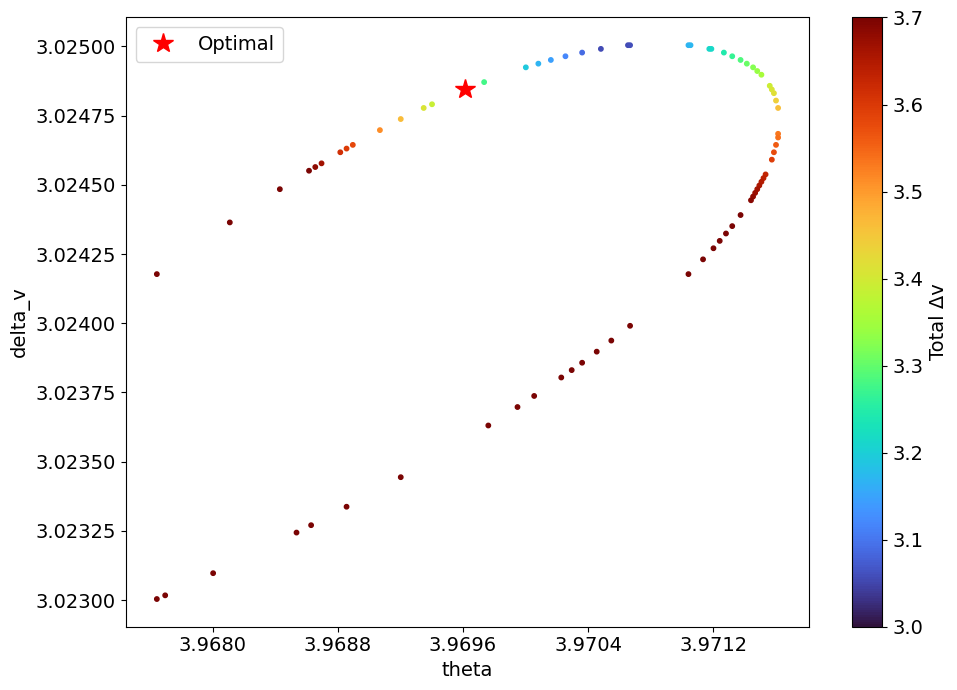

3.9706556509695288 3.0250041828254846 0.074609375 0.7299271700356719


C:\Users\scoul\AppData\Local\Temp\ipykernel_8844\1930148173.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(min_row[0], min_row[1], min_row[2], min_row[3])


In [15]:
theta_delta_v_sweep = run_sensitivity('theta', theta_delta, 'delta_v', delta_v_delta)
min_row = theta_delta_v_sweep.loc[theta_delta_v_sweep['total_delta_v'].idxmin()]
print(min_row[0], min_row[1], min_row[2], min_row[3])

## Theta v Alpha

Loading cached theta vs delta_v_angle sweep...
  min Δv = 3.044495,  dist to LMO = -2.302908e-06


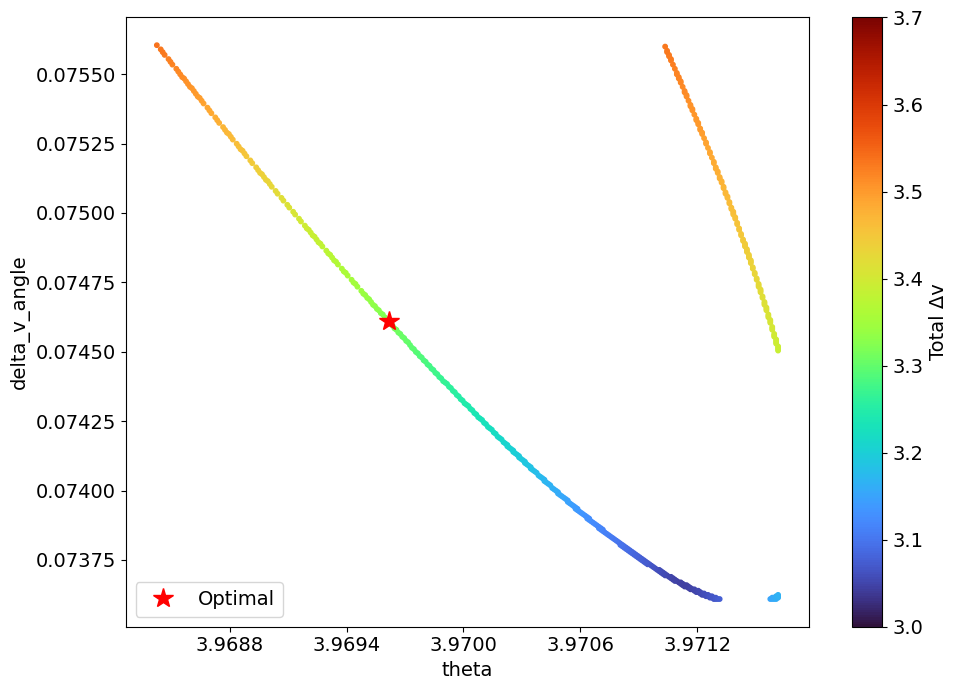

In [9]:
theta_alpha_sweep = run_sensitivity('theta', theta_delta, 'delta_v_angle', delta_v_angle_delta, grid_size=401)

## Theta v ToF

Loading cached theta vs tof sweep...
  min Δv = 3.110120,  dist to LMO = 2.224002e-06


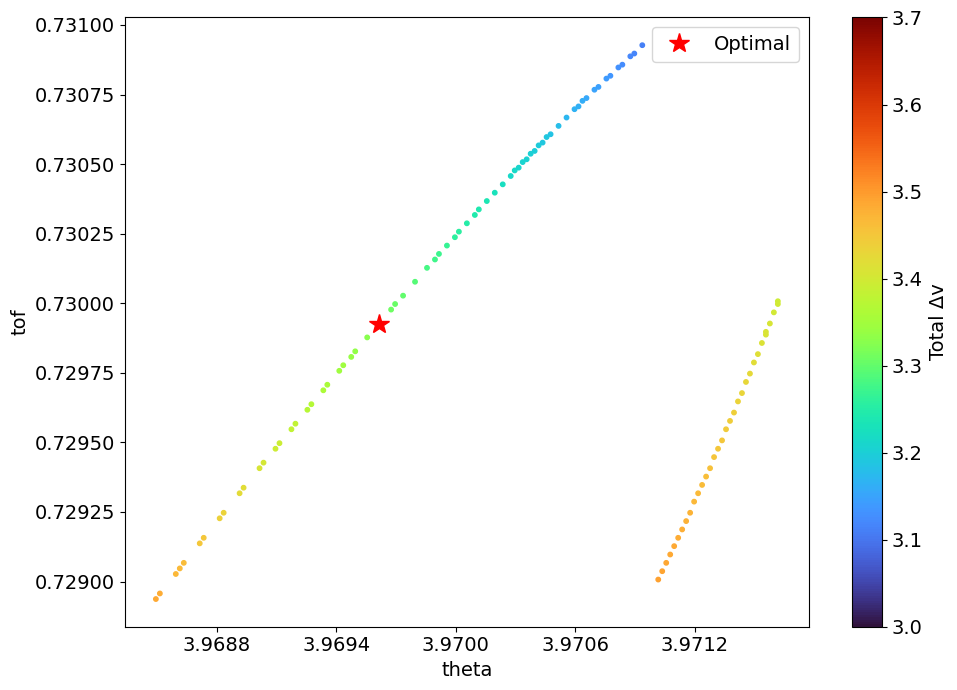

In [10]:
theta_tof_sweep = run_sensitivity('theta', theta_delta, 'tof', tof_delta)

## Delta_v v Alpha

Loading cached delta_v vs delta_v_angle sweep...
  min Δv = 3.146122,  dist to LMO = 1.954214e-06


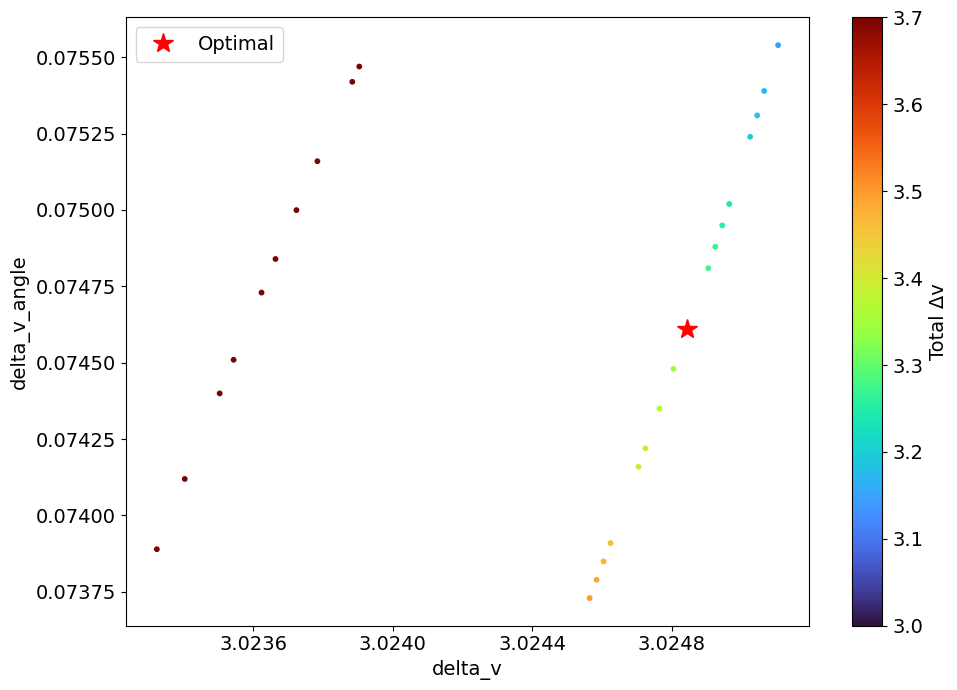

In [11]:
delta_v_alpha_sweep = run_sensitivity('delta_v', delta_v_delta, 'delta_v_angle', delta_v_angle_delta)

## Delta_v v ToF

Loading cached delta_v vs tof sweep...
  min Δv = 3.121126,  dist to LMO = -1.630859e-06


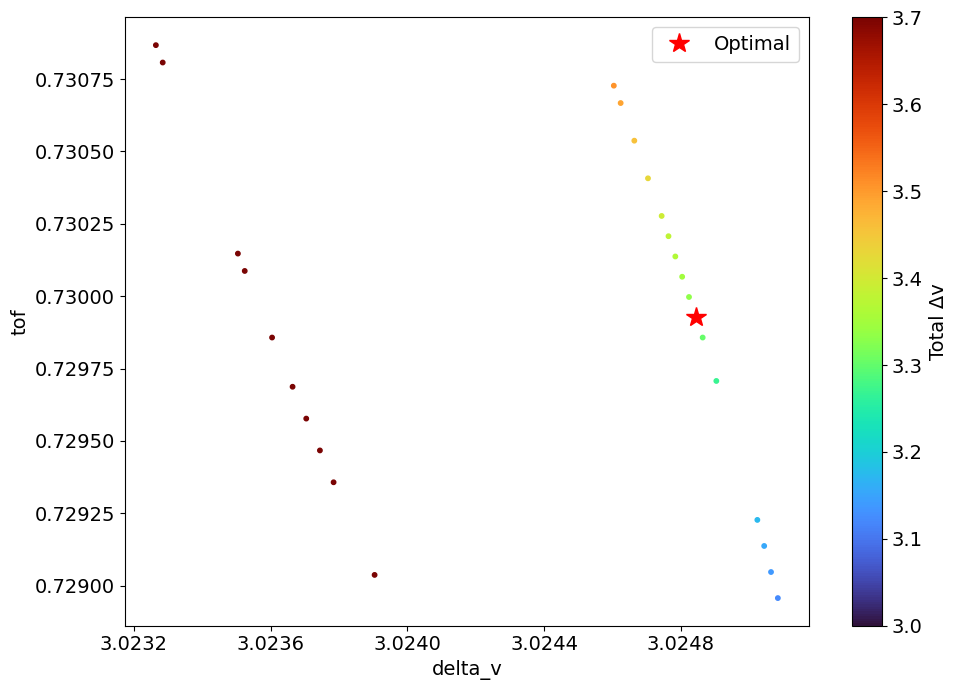

In [12]:
delta_v_tof_sweep = run_sensitivity('delta_v', delta_v_delta, 'tof', tof_delta)

## Alpha v ToF

Loading cached delta_v_angle vs tof sweep...
  min Δv = 3.282446,  dist to LMO = 2.273415e-06


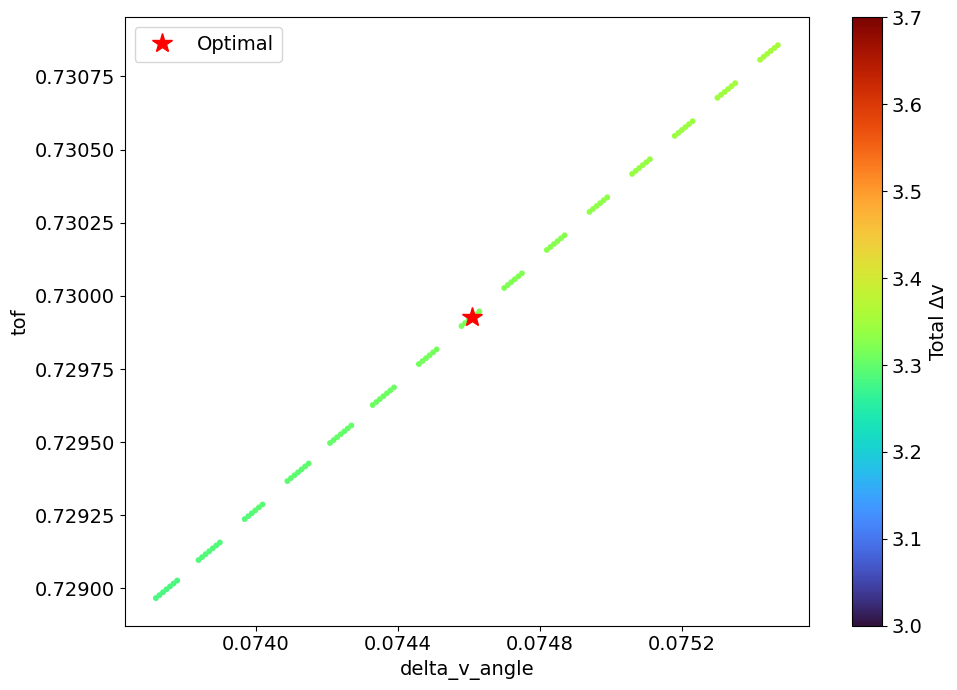

In [13]:
alpha_tof_sweep = run_sensitivity('delta_v_angle', delta_v_angle_delta, 'tof', tof_delta)